# Nexqori · Limpieza y análisis inicial para detectar intenciones

**Objetivo:** establecer qué datos existen realmente, limpiar sin alterar originales y determinar si el texto permite construir una evaluación de intenciones. Se analizan todas las filas y columnas de las tablas CSV descubiertas; el detalle lingüístico se concentra en atención al cliente.

**Lectura:** 1) fuente y cobertura, 2) esquema/calidad, 3) limpieza, 4) tiempo/idioma, 5) señales de intención, 6) conclusiones y validación. Los números se calculan durante la ejecución; no se reutilizan los agregados del EDA anterior.

**Límites:** datos sintéticos históricos. Motivo de contacto, intención textual y resultado de negocio son conceptos diferentes. No hay entrenamiento, llamadas a LLM/Jev, envío externo, operaciones bancarias ni cambios en la app. Los datos derivados quedan en `private/`, excluido de Git.

In [1]:
from pathlib import Path
from collections import defaultdict, Counter
from datetime import datetime
from zoneinfo import ZoneInfo
import os, sys, re, csv, json, hashlib, unicodedata, time, platform

DATASET_OVERRIDE = None  # Ruta explícita opcional; no introducir credenciales.
here = Path.cwd().resolve()
ROOT = next(p for p in [here, *here.parents] if (p / 'backend/assistant.py').exists())
OUT = ROOT / 'notebooks/intentions'
for name in ['results', 'figures', 'private', 'runtime']:
    (OUT / name).mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(OUT / 'runtime/matplotlib')
import duckdb
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image, HTML
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 16)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.facecolor': '#FFFCF9', 'axes.facecolor': '#FFFCF9'})
COLORS = ['#9A4B32', '#526D82', '#668B6B', '#B08550', '#8A7291', '#557F7F']
START = time.perf_counter()
def save_json(name, value, folder='results'):
    (OUT / folder / name).write_text(json.dumps(value, ensure_ascii=False, indent=2, default=str), encoding='utf-8')
def save_df(name, frame):
    frame.to_csv(OUT / 'results' / (name + '.csv'), index=False, encoding='utf-8')
    return frame
def qi(v): return '"' + str(v).replace('"', '""') + '"'
def qs(v): return "'" + str(v).replace("'", "''") + "'"
def scalar(sql): return con.execute(sql).fetchone()[0]
def show_fig(fig, name):
    fig.savefig(OUT / 'figures' / (name + '.png'), dpi=150, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(OUT / 'figures' / (name + '.png'))))

candidates = [Path(DATASET_OVERRIDE)] if DATASET_OVERRIDE else []
if os.getenv('NEXQORI_DATASET_DIR'): candidates.append(Path(os.environ['NEXQORI_DATASET_DIR']))
candidates += [ROOT.parent / 'nexqori-dataset', ROOT / 'dataset']
DATA = next((p.resolve() for p in candidates if p.is_dir() and any(p.rglob('*.csv'))), None)
if DATA is None:
    raise FileNotFoundError('No hay CSV reales. Configurar DATASET_OVERRIDE o NEXQORI_DATASET_DIR; no se generan datos de reemplazo.')
assert DATA != OUT and OUT not in DATA.parents
print('Raíz del proyecto:', ROOT)
print('Fuente real:', DATA)
print('Resultados:', OUT)
print('Ejecución America/Lima:', datetime.now(ZoneInfo('America/Lima')).isoformat())

Raíz del proyecto: C:\Users\santi\Documents\Projects\nexqori
Fuente real: C:\Users\santi\Documents\Projects\nexqori-dataset
Resultados: C:\Users\santi\Documents\Projects\nexqori\notebooks\intentions
Ejecución America/Lima: 2026-09-29T14:34:43.042556-05:00


## 1. Inventario físico y cambios de esquema

Se recorren archivos reales, no rutas del repositorio anterior. Cada CSV se identifica por tabla, tamaño, fecha de modificación y SHA-256 de contenido. Se leen todas las cabeceras para detectar diferencias entre particiones. El manifiesto completo queda local. Diferencias de esquema se registran; errores de parseo detienen la ejecución en lugar de omitir filas.

In [2]:
PK = {'branches':['branch_id'], 'customers':['customer_id'], 'products':['product_id'],
      'service_agents':['agent_id'], 'marketing_campaigns':['campaign_id'],
      'daily_exchange_rates':['date','source_currency','target_currency'],
      'transactions':['transaction_id'], 'digital_events':['event_id'],
      'campaign_sends':['send_id'], 'call_center_interactions':['interaction_id'],
      'call_transcripts':['transcript_id'], 'complaints':['complaint_id'],
      'satisfaction_surveys':['survey_id']}
FOCUS = ['call_center_interactions', 'call_transcripts', 'complaints', 'satisfaction_surveys']
groups, schemas, inventory = defaultdict(list), defaultdict(Counter), []
unrecognized = []
for path in sorted(DATA.rglob('*.csv')):
    rel = path.relative_to(DATA)
    table = rel.parts[0] if len(rel.parts) > 1 else path.stem
    if table not in PK:
        unrecognized.append(str(rel)); continue
    with path.open('r', encoding='utf-8-sig', newline='') as f:
        header = tuple(next(csv.reader(f)))
    if len(header) != len(set(header)): raise ValueError(f'Cabecera duplicada: {rel}')
    with path.open('rb') as source:
        sha = hashlib.file_digest(source, 'sha256').hexdigest()
    st = path.stat()
    groups[table].append(path)
    schemas[table][header] += 1
    inventory.append({'table':table, 'relative_path':str(rel), 'bytes':st.st_size,
                      'mtime_ns':st.st_mtime_ns, 'sha256':sha})
if not all(t in groups for t in FOCUS):
    raise ValueError('Faltan tablas de atención: ' + str(set(FOCUS)-set(groups)))
save_json('input_manifest.json', {'root':str(DATA), 'files':inventory, 'unrecognized':unrecognized}, 'private')
file_summary = save_df('files', pd.DataFrame([
    {'table':t, 'files':len(fs), 'bytes':sum(p.stat().st_size for p in fs),
     'schema_variants':len(schemas[t]), 'first_file':str(fs[0].relative_to(DATA)),
     'last_file':str(fs[-1].relative_to(DATA))} for t,fs in sorted(groups.items())]))
schema_rows = [{'table':t,'schema_variant':j+1,'files':n,'columns':len(cols),
                'column_names':' | '.join(cols)} for t, variants in schemas.items()
               for j,(cols,n) in enumerate(variants.items())]
save_df('schema_variants', pd.DataFrame(schema_rows))
display(file_summary)
print(f'Inventario: {len(inventory):,} CSV; {sum(x["bytes"] for x in inventory):,} bytes; {len(groups)} tablas.')
print('Archivos CSV no reconocidos (no analizados):', len(unrecognized))

,table,files,bytes,schema_variants,first_file,last_file
0,branches,1,89529,1,branches.csv,branches.csv
1,call_center_interactions,1097,139734950,1,call_center_interactions\year=2023\month=06\da...,call_center_interactions\year=2026\month=06\da...
2,call_transcripts,1097,137235657,1,call_transcripts\year=2023\month=06\day=17\cal...,call_transcripts\year=2026\month=06\day=17\cal...
3,campaign_sends,1083,325976325,1,campaign_sends\year=2023\month=07\day=01\campa...,campaign_sends\year=2026\month=06\day=17\campa...
4,complaints,1097,17990612,1,complaints\year=2023\month=06\day=17\complaint...,complaints\year=2026\month=06\day=17\complaint...
5,customers,1,46897358,1,customers.csv,customers.csv
6,daily_exchange_rates,1,778914,1,daily_exchange_rates.csv,daily_exchange_rates.csv
7,digital_events,1097,3757355051,1,digital_events\year=2023\month=06\day=17\digit...,digital_events\year=2026\month=06\day=17\digit...
8,marketing_campaigns,1,32710,1,marketing_campaigns.csv,marketing_campaigns.csv
9,products,1,68213646,1,products.csv,products.csv


Inventario: 7,671 CSV; 5,349,322,481 bytes; 13 tablas.
Archivos CSV no reconocidos (no analizados): 0


## 2. Columnas, tipos, nulos y duplicados — censo completo

CSV no conserva tipos de base de datos: se ingiere como VARCHAR para no perder ceros de IDs, códigos o teléfonos. Se informa **tipo analítico esperado según semántica del diccionario (DOUBLE agrupa medidas numéricas; no replica precisión/escala SQL)**, y conversiones inválidas sobre todas las filas. No se confunde almacenamiento textual con un error. Vacío = NULL de CSV o cadena de espacios. No se imputan textos, etiquetas, IDs ni fechas.

Duplicados de clave se miden sin contar claves nulas; duplicados de fila son repeticiones exactas de todas las columnas originales, excluyendo ruta de archivo. Si todas las claves están presentes y son únicas, matemáticamente no puede haber filas idénticas; se evita una agrupación innecesaria de millones de filas.

In [3]:
NUM = {
 'branches':'atm_count teller_window_count latitude longitude',
 'customers':'credit_score estimated_monthly_income',
 'products':'current_balance credit_limit interest_rate days_past_due',
 'service_agents':'avg_csat total_monthly_interactions',
 'marketing_campaigns':'budget expected_conversion_rate',
 'daily_exchange_rates':'exchange_rate buy_rate sell_rate',
 'call_center_interactions':'duration_seconds wait_time_seconds sentiment_score',
 'call_transcripts':'accent_confidence duration_seconds',
 'complaints':'claimed_amount resolution_days compensation_granted resolution_satisfaction',
 'satisfaction_surveys':'main_score question_1_response question_2_response question_3_response response_time_hours campaign_response_rate',
 'transactions':'amount amount_usd fraud_score latitude longitude',
 'digital_events':'event_value duration_seconds',
 'campaign_sends':'click_count conversion_value send_cost'}
DESCRIPTIONS = {
 'customer_text':'Texto del cliente: candidato principal para intención; no etiqueta.',
 'full_text':'Conversación completa: contiene agente y posible información posterior.',
 'agent_text':'Texto del agente: excluir de predicción inicial para evitar fuga.',
 'detected_intents':'Intenciones históricas detectadas; necesitan revisión humana.',
 'contact_reason':'Motivo histórico registrado, no verdad textual garantizada.',
 'reason_category':'Categoría histórica; comparar contra evidencia textual.',
 'description':'Descripción libre; evaluar repetición y especificidad.',
 'open_comments':'Comentario posterior de encuesta: dominio distinto al pedido inicial.',
 'detected_language':'Idioma declarado por el origen, no detección independiente.',
 'accent_confidence':'Confianza del acento; NO probabilidad de intención.',
 'has_transcript':'Indicador de transcripción; verificar existencia real por ID.',
 'process_date':'Fecha de partición/proceso; no asumir fecha de ocurrencia o disponibilidad.',
 'resolution':'Resultado posterior del reclamo: excluir del input inicial.',
 'was_resolved':'Resultado histórico; no usar para clasificar pedido inicial.',
 'was_escalated':'Escalamiento histórico; no usar como entrada inicial.',
 'mentioned_entities':'Entidades derivadas del origen; no contexto verificado.',
 'detected_keywords':'Palabras detectadas por origen; no etiquetas revisadas.',
 'main_topics':'Temas históricos; su coherencia textual debe comprobarse.'}
def expected_type(t,c):
    if c in NUM.get(t,'').split(): return 'DOUBLE'
    if c.startswith(('has_','was_','is_')) or c in ['accepts_marketing','requires_followup','had_conversion','sla_breached']: return 'BOOLEAN'
    if c in ['date','process_date']: return 'DATE'
    if c.endswith('_date') or c in ['last_updated','date_of_birth']: return 'TIMESTAMP'
    if c in ['opening_time','closing_time']: return 'TIME'
    return 'VARCHAR'
def description(t,c):
    if c in DESCRIPTIONS: return DESCRIPTIONS[c]
    if c.endswith('_id'): return 'Identificador / referencia; conservar texto y comprobar vínculo antes de unir.'
    if 'accent' in c: return 'Acento declarado; no demuestra idioma ni intención.'
    if expected_type(t,c) in ['DATE','TIMESTAMP','TIME']: return 'Campo temporal ' + c + '; semántica y zona dependen del origen.'
    if expected_type(t,c)=='BOOLEAN': return 'Indicador booleano del origen: ' + c
    if expected_type(t,c)=='DOUBLE': return 'Medida numérica del origen: ' + c + '; no imputada ni sumada entre monedas.'
    return 'Atributo textual/categórico del origen: ' + c + '; conservar dominio original.'

con = duckdb.connect(str(OUT/'runtime/intentions.duckdb'))
con.execute("SET memory_limit='1500MB'")
con.execute('SET threads=4')
con.execute('SET preserve_insertion_order=false')
con.execute(f"SET temp_directory={qs((OUT/'runtime/spill').as_posix())}")
tables, profile_rows, summary_rows = {}, [], []
for t, files in sorted(groups.items()):
    print('Perfilando',t,flush=True)
    save_json('progress.json', {'table':t,'completed':len(summary_rows)}, 'runtime')
    paths = '[' + ','.join(qs(p.as_posix()) for p in files) + ']'
    con.execute('DROP TABLE IF EXISTS current_raw')
    con.execute(f'''CREATE TABLE current_raw AS SELECT * FROM read_csv({paths},
        header=true, all_varchar=true, union_by_name=true, hive_partitioning=false,
        filename='__source_file', nullstr='', strict_mode=true, ignore_errors=false)''')
    cols = [r[0] for r in con.execute('DESCRIBE current_raw').fetchall() if r[0]!='__source_file']
    tables[t] = cols
    n = scalar('SELECT count(*) FROM current_raw')
    # Una agregación sin cardinalidades masivas para métricas por columna.
    expressions = []
    for c in cols:
        q=qi(c); clean=f'nullif(trim({q}),\'\')'; typ=expected_type(t,c)
        expressions += [f'count(*) FILTER (WHERE {q} IS NULL)',
                        f'count(*) FILTER (WHERE {q} IS NOT NULL AND trim({q})=\'\')',
                        f'count(*) FILTER (WHERE contains({q},chr(65533)))',
                        f'count(*) FILTER (WHERE {clean} IS NOT NULL AND TRY_CAST({clean} AS {typ}) IS NULL)' if typ!='VARCHAR' else '0']
    metrics = con.execute('SELECT '+','.join(expressions)+' FROM current_raw').fetchone()
    for j,c in enumerate(cols):
        nulls,blank,repl,invalid = metrics[4*j:4*j+4]
        profile_rows.append({'table':t,'column':c,'description':description(t,c),
            'csv_storage_type':'VARCHAR','expected_type':expected_type(t,c),'rows':n,
            'nulls':nulls,'blank_strings':blank,'missing_total':nulls+blank,
            'missing_pct':100*(nulls+blank)/n if n else 0,
            'replacement_character_rows':repl,'invalid_cast_nonmissing':invalid})
    keycols=PK[t]
    if not set(keycols)<=set(cols): raise ValueError('Faltan claves en '+t)
    valid=' AND '.join(f'nullif(trim({qi(c)}),\'\') IS NOT NULL' for c in keycols)
    keyselect=','.join(qi(c) for c in keycols)
    key_null=scalar(f'SELECT count(*) FROM current_raw WHERE NOT ({valid})')
    key_unique=scalar(f'SELECT count(*) FROM (SELECT DISTINCT {keyselect} FROM current_raw WHERE {valid})')
    key_dup=n-key_null-key_unique
    row_dup=0 if key_null==0 and key_dup==0 else n-scalar(f'SELECT count(*) FROM (SELECT DISTINCT {",".join(map(qi,cols))} FROM current_raw)')
    summary_rows.append({'table':t,'rows':n,'columns':len(cols),'missing_cells':sum(r['missing_total'] for r in profile_rows if r['table']==t),
        'null_key_rows':key_null,'duplicate_key_extra_rows':key_dup,'exact_duplicate_extra_rows':row_dup})
    # Guardar cuatro fuentes de atención, sin copia cruda del resto del banco.
    if t in FOCUS:
        con.execute(f'CREATE OR REPLACE TABLE {qi(t+"_raw")} AS SELECT * FROM current_raw')
    # Fechas se resumen mientras cada tabla está cargada.
    datecols=[c for c in cols if expected_type(t,c) in ['DATE','TIMESTAMP']]
    for c in datecols:
        q=qi(c)
        row=con.execute(f'SELECT min(TRY_CAST({q} AS TIMESTAMP)),max(TRY_CAST({q} AS TIMESTAMP)), count(DISTINCT CAST(TRY_CAST({q} AS TIMESTAMP) AS DATE)) FROM current_raw').fetchone()
        if 'temporal_rows' not in globals(): temporal_rows=[]
        temporal_rows.append({'table':t,'column':c,'min':row[0],'max':row[1],'distinct_days':row[2],
                              'timezone':'No declarada en CSV; no convertir ni asumir UTC'})
    print(f'  {n:,} filas, {len(cols)} columnas, {key_dup:,} claves repetidas',flush=True)
con.execute('DROP TABLE current_raw')
summary=save_df('table_quality',pd.DataFrame(summary_rows))
profile=save_df('column_profile',pd.DataFrame(profile_rows))
temporal=save_df('temporal_coverage',pd.DataFrame(temporal_rows))
display(summary)
display(profile[profile.table.isin(FOCUS)])
for table_name, fields in profile.groupby('table'):
    display(HTML('<details><summary>Perfil completo: '+table_name+'</summary>'+fields.to_html(index=False,escape=True)+'</details>'))
print('Perfil completo de todas las columnas: results/column_profile.csv')

Perfilando branches


  350 filas, 22 columnas, 0 claves repetidas


Perfilando call_center_interactions


  686,296 filas, 21 columnas, 0 claves repetidas


Perfilando call_transcripts


...

table,column,description,csv_storage_type,expected_type,rows,nulls,blank_strings,missing_total,missing_pct,replacement_character_rows,invalid_cast_nonmissing
products,product_id,Identificador / referencia; conservar texto y comprobar vínculo antes de unir.,VARCHAR,VARCHAR,400000,0,0,0,0.00000,0,0
products,customer_id,Identificador / referencia; conservar texto y comprobar vínculo antes de unir.,VARCHAR,VARCHAR,400000,0,0,0,0.00000,0,0
products,product_type,Atributo textual/categórico del origen: product_type; conservar dominio original.,VARCHAR,VARCHAR,400000,0,0,0,0.00000,0,0
products,product_number,Atributo textual/categórico del origen: product_number; conservar dominio original.,VARCHAR,VARCHAR,400000,0,0,0,0.00000,0,0
products,currency,Atributo textual/categórico del origen: currency; conservar dominio original.,VARCHAR,VARCHAR,400000,0,0,0,0.00000,0,0
products,current_balance,Medida numérica del origen: current_balance; no imputada ni sumada entre monedas.,VARCHAR,DOUBLE,400000,0,0,0,0.00000,0,0
products,credit_limit,Medida numérica del origen: credit_limit; no imputada ni sumada entre monedas.,VARCHAR,DOUBLE,400000,274683,0,274683,68.67075,0,0
products,interest_rate,Medida numérica del origen: interest_rate; no imputada ni sumada entre monedas.,VARCHAR,DOUBLE,400000,40066,0,40066,10.01650,0,0
products,opening_date,Campo temporal opening_date; semántica y zona dependen del origen.,VARCHAR,TIMESTAMP,400000,0,0,0,0.00000,0,0
products,expiration_date,Campo temporal expiration_date; semántica y zona dependen del origen.,VARCHAR,TIMESTAMP,400000,266839,0,266839,66.70975,0,0


table,column,description,csv_storage_type,expected_type,rows,nulls,blank_strings,missing_total,missing_pct,replacement_character_rows,invalid_cast_nonmissing
satisfaction_surveys,survey_id,Identificador / referencia; conservar texto y comprobar vínculo antes de unir.,VARCHAR,VARCHAR,212759,0,0,0,0.000000,0,0
satisfaction_surveys,survey_date,Campo temporal survey_date; semántica y zona dependen del origen.,VARCHAR,TIMESTAMP,212759,0,0,0,0.000000,0,0
satisfaction_surveys,process_date,Fecha de partición/proceso; no asumir fecha de ocurrencia o disponibilidad.,VARCHAR,DATE,212759,0,0,0,0.000000,0,0
satisfaction_surveys,interaction_id,Identificador / referencia; conservar texto y comprobar vínculo antes de unir.,VARCHAR,VARCHAR,212759,0,0,0,0.000000,0,0
satisfaction_surveys,customer_id,Identificador / referencia; conservar texto y comprobar vínculo antes de unir.,VARCHAR,VARCHAR,212759,0,0,0,0.000000,0,0
satisfaction_surveys,agent_id,Identificador / referencia; conservar texto y comprobar vínculo antes de unir.,VARCHAR,VARCHAR,212759,0,0,0,0.000000,0,0
satisfaction_surveys,survey_type,Atributo textual/categórico del origen: survey_type; conservar dominio original.,VARCHAR,VARCHAR,212759,0,0,0,0.000000,0,0
satisfaction_surveys,send_channel,Atributo textual/categórico del origen: send_channel; conservar dominio original.,VARCHAR,VARCHAR,212759,0,0,0,0.000000,0,0
satisfaction_surveys,main_score,Medida numérica del origen: main_score; no imputada ni sumada entre monedas.,VARCHAR,DOUBLE,212759,0,0,0,0.000000,0,0
satisfaction_surveys,nps_category,Atributo textual/categórico del origen: nps_category; conservar dominio original.,VARCHAR,VARCHAR,212759,152365,0,152365,71.613892,0,0


table,column,description,csv_storage_type,expected_type,rows,nulls,blank_strings,missing_total,missing_pct,replacement_character_rows,invalid_cast_nonmissing
service_agents,agent_id,Identificador / referencia; conservar texto y comprobar vínculo antes de unir.,VARCHAR,VARCHAR,1200,0,0,0,0.000000,0,0
service_agents,employee_code,Atributo textual/categórico del origen: employee_code; conservar dominio original.,VARCHAR,VARCHAR,1200,0,0,0,0.000000,0,0
service_agents,first_name,Atributo textual/categórico del origen: first_name; conservar dominio original.,VARCHAR,VARCHAR,1200,0,0,0,0.000000,0,0
service_agents,last_name,Atributo textual/categórico del origen: last_name; conservar dominio original.,VARCHAR,VARCHAR,1200,0,0,0,0.000000,0,0
service_agents,email,Atributo textual/categórico del origen: email; conservar dominio original.,VARCHAR,VARCHAR,1200,0,0,0,0.000000,0,0
service_agents,phone,Atributo textual/categórico del origen: phone; conservar dominio original.,VARCHAR,VARCHAR,1200,69,0,69,5.750000,0,0
service_agents,native_accent,Acento declarado; no demuestra idioma ni intención.,VARCHAR,VARCHAR,1200,0,0,0,0.000000,0,0
service_agents,country_of_origin,Atributo textual/categórico del origen: country_of_origin; conservar dominio original.,VARCHAR,VARCHAR,1200,0,0,0,0.000000,0,0
service_agents,assigned_branch_id,Identificador / referencia; conservar texto y comprobar vínculo antes de unir.,VARCHAR,VARCHAR,1200,367,0,367,30.583333,0,0
service_agents,agent_type,Atributo textual/categórico del origen: agent_type; conservar dominio original.,VARCHAR,VARCHAR,1200,0,0,0,0.000000,0,0


table,column,description,csv_storage_type,expected_type,rows,nulls,blank_strings,missing_total,missing_pct,replacement_character_rows,invalid_cast_nonmissing
transactions,transaction_id,Identificador / referencia; conservar texto y comprobar vínculo antes de unir.,VARCHAR,VARCHAR,4425008,0,0,0,0.000000,0,0
transactions,transaction_date,Campo temporal transaction_date; semántica y zona dependen del origen.,VARCHAR,TIMESTAMP,4425008,0,0,0,0.000000,0,0
transactions,process_date,Fecha de partición/proceso; no asumir fecha de ocurrencia o disponibilidad.,VARCHAR,DATE,4425008,0,0,0,0.000000,0,0
transactions,product_id,Identificador / referencia; conservar texto y comprobar vínculo antes de unir.,VARCHAR,VARCHAR,4425008,0,0,0,0.000000,0,0
transactions,customer_id,Identificador / referencia; conservar texto y comprobar vínculo antes de unir.,VARCHAR,VARCHAR,4425008,0,0,0,0.000000,0,0
transactions,transaction_type,Atributo textual/categórico del origen: transaction_type; conservar dominio original.,VARCHAR,VARCHAR,4425008,0,0,0,0.000000,0,0
transactions,transaction_category,Atributo textual/categórico del origen: transaction_category; conservar dominio original.,VARCHAR,VARCHAR,4425008,2693520,0,2693520,60.870398,0,0
transactions,amount,Medida numérica del origen: amount; no imputada ni sumada entre monedas.,VARCHAR,DOUBLE,4425008,0,0,0,0.000000,0,0
transactions,currency,Atributo textual/categórico del origen: currency; conservar dominio original.,VARCHAR,VARCHAR,4425008,0,0,0,0.000000,0,0
transactions,amount_usd,Medida numérica del origen: amount_usd; no imputada ni sumada entre monedas.,VARCHAR,DOUBLE,4425008,2537456,0,2537456,57.343535,0,0


Perfil completo de todas las columnas: results/column_profile.csv


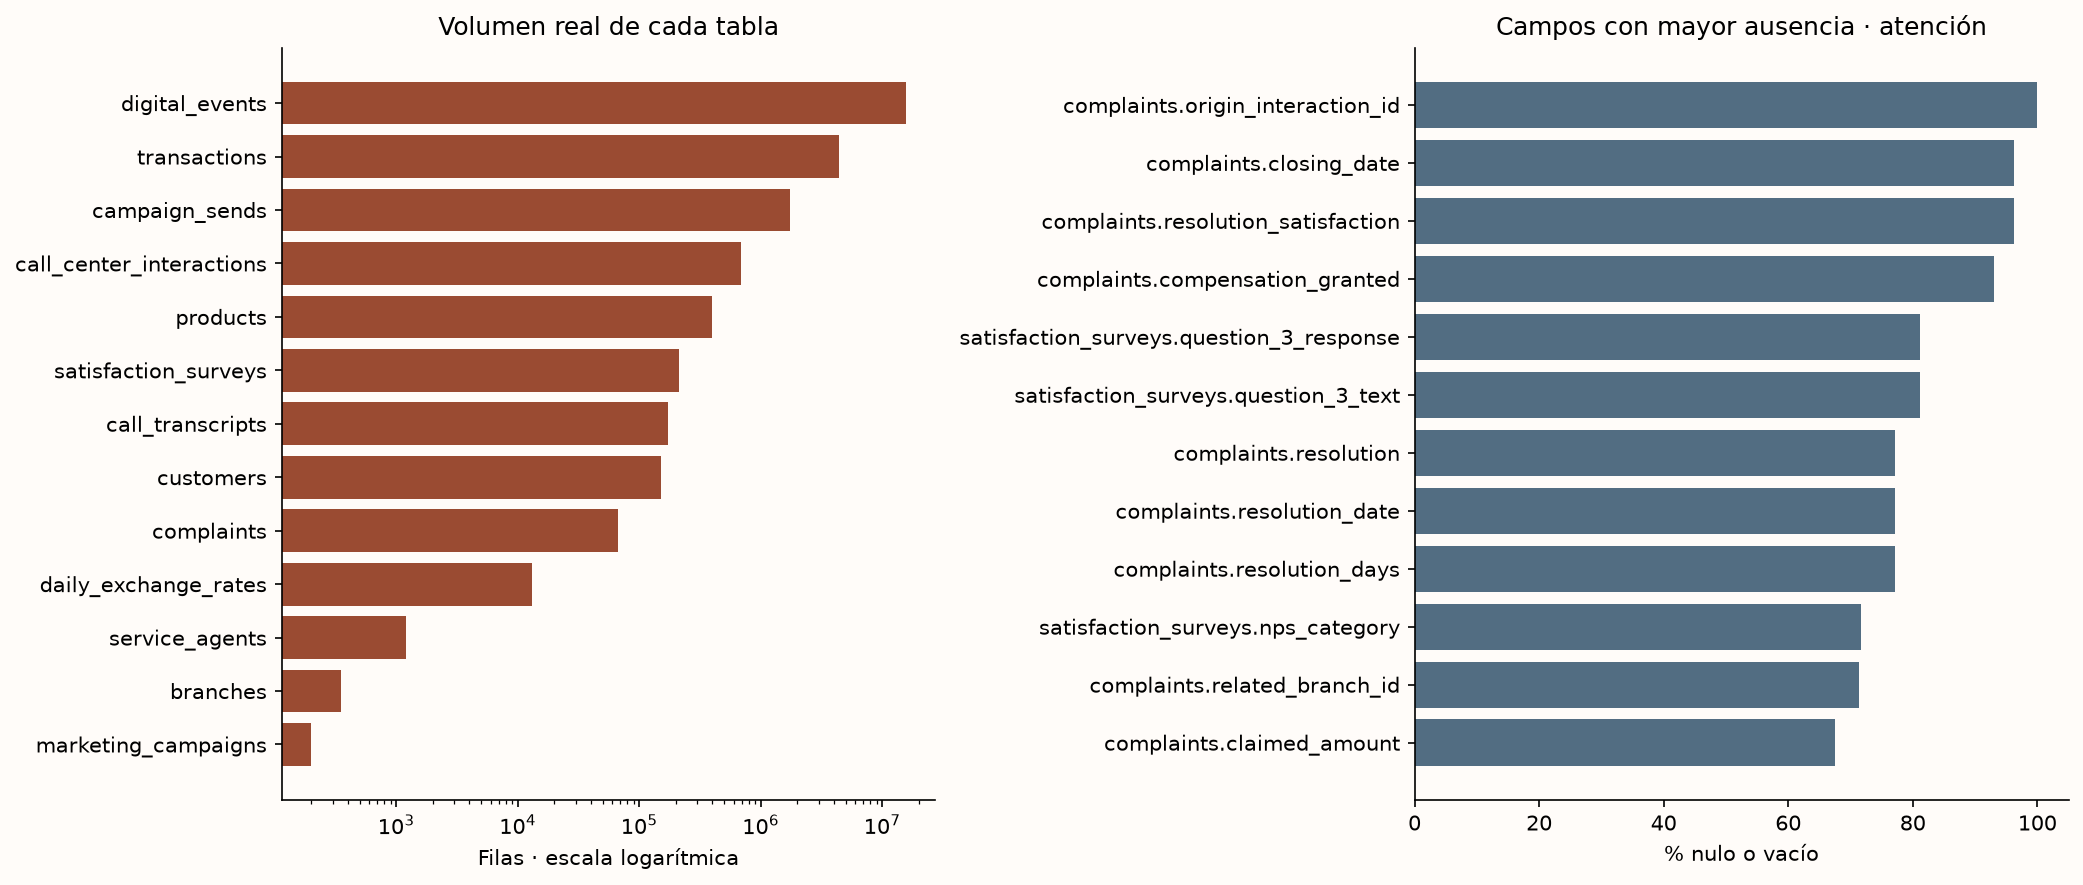

In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,6))
ordered=summary.sort_values('rows')
axes[0].barh(ordered.table,ordered.rows,color=COLORS[0])
axes[0].set_xscale('log'); axes[0].set_xlabel('Filas · escala logarítmica'); axes[0].set_title('Volumen real de cada tabla')
missing=profile[profile.table.isin(FOCUS)].sort_values('missing_pct').tail(12)
axes[1].barh(missing.table.str.replace('call_center_interactions','interacciones')+'.'+missing.column,missing.missing_pct,color=COLORS[1])
axes[1].set_xlim(0,105); axes[1].set_xlabel('% nulo o vacío'); axes[1].set_title('Campos con mayor ausencia · atención')
fig.tight_layout(); show_fig(fig,'01_volumen_nulos')

## 3. Limpieza conservadora y corpus local

Se preservan los originales. En copias de las cuatro tablas de atención: se recortan espacios de borde y vacíos pasan a NULL; los campos narrativos normalizan Unicode NFC y espacios repetidos. No se quitan acentos, negaciones, puntuación ni palabras. No se corrigen etiquetas mediante suposiciones. Fechas inválidas no se silencian: constan en el perfil y se conservan como texto en las copias.

El corpus inicial usa **sólo `customer_text`**, `complaints.description` y `satisfaction_surveys.open_comments`, en dominios separados. No se usa `full_text` como reemplazo automático porque podría incluir respuestas del agente. No se borran filas por compartir texto: se asigna una huella para agrupar duplicados y evitar fuga entre particiones. No se filtran palabras como “no”, importantes para reconocer una disputa.

In [5]:
def normalize_text(s):
    return re.sub(r'\s+', ' ', unicodedata.normalize('NFC',s)).strip() if s is not None else None
con.create_function('clean_narrative', normalize_text, ['VARCHAR'], 'VARCHAR')
text_fields={'customer_text','full_text','agent_text','description','resolution','open_comments'}
cleaning_rows=[]
for t in FOCUS:
    cols=tables[t]
    selection=[]
    for c in cols:
        expression=f'clean_narrative({qi(c)})' if c in text_fields else f'trim({qi(c)})'
        selection.append(f'nullif({expression},\'\') AS {qi(c)}')
    con.execute(f'CREATE OR REPLACE TABLE {qi(t)} AS SELECT {",".join(selection)},__source_file FROM {qi(t+"_raw")}')
    for c in cols:
        changes=scalar(f'SELECT count(*) FROM {qi(t+"_raw")} WHERE {qi(c)} IS DISTINCT FROM nullif('+ (f'clean_narrative({qi(c)})' if c in text_fields else f'trim({qi(c)})') + ", '')")
        cleaning_rows.append({'table':t,'column':c,'changed_rows':changes,'operation':'NFC + espacios + vacío a NULL' if c in text_fields else 'trim + vacío a NULL'})
    path=OUT/'private'/f'{t}_clean.parquet'
    con.execute(f'COPY {qi(t)} TO {qs(path.as_posix())} (FORMAT PARQUET, COMPRESSION ZSTD)')
cleaning=save_df('cleaning_audit',pd.DataFrame(cleaning_rows))
sources=[('call_transcripts','transcript_id','customer_text'),('complaints','complaint_id','description'),('satisfaction_surveys','survey_id','open_comments')]
parts=[]
for t,idcol,field in sources:
    parts.append(f'''SELECT {qs(t)} AS source_table,{qi(idcol)} AS source_id,
        {qi(field)} AS clean_text,sha256(lower({qi(field)})) AS text_group,
        TRY_CAST(process_date AS DATE) AS process_date,
        {('detected_language' if t=='call_transcripts' else 'NULL::VARCHAR')} AS declared_language
        FROM {qi(t)} WHERE {qi(field)} IS NOT NULL''')
con.execute('CREATE OR REPLACE TABLE corpus AS '+' UNION ALL '.join(parts))
con.execute(f"COPY corpus TO {qs((OUT/'private/intent_candidates.parquet').as_posix())} (FORMAT PARQUET, COMPRESSION ZSTD)")
text_stats=save_df('text_quality',con.execute('''SELECT source_table,count(*) AS rows_with_text,
    count(DISTINCT clean_text) distinct_clean_texts,count(DISTINCT text_group) normalized_groups,
    min(length(clean_text)) min_chars,median(length(clean_text)) median_chars,
    max(length(clean_text)) max_chars FROM corpus GROUP BY source_table ORDER BY source_table''').df())
raw_text_counts=[]
for t,_,field in sources:
    raw_text_counts.append({'source_table':t,'raw_nonnull':scalar(f'SELECT count({qi(field)}) FROM {qi(t+"_raw")}'),
        'raw_unique_texts':scalar(f'SELECT count(DISTINCT {qi(field)}) FROM {qi(t+"_raw")}')})
text_stats=save_df('text_quality',text_stats.merge(pd.DataFrame(raw_text_counts),on='source_table',validate='one_to_one'))
display(text_stats)
display(cleaning[cleaning.changed_rows>0])

,source_table,rows_with_text,distinct_clean_texts,normalized_groups,min_chars,median_chars,max_chars,raw_nonnull,raw_unique_texts
0,call_transcripts,171321,42,42,68,82.0,162,171321,42
1,complaints,67095,5,5,26,29.0,34,67095,5
2,satisfaction_surveys,101196,13,13,10,34.0,48,101196,13


,table,column,changed_rows,operation
26,call_transcripts,full_text,171321,NFC + espacios + vacío a NULL


## 4. Cobertura temporal e idiomática

Se distinguen fecha de partición y fecha de evento. Un intervalo mínimo–máximo no significa que todos sus días estén representados; se cuentan fechas y huecos. Las fechas no contienen una zona horaria declarada. Fecha de nacimiento o vencimiento no describe cobertura de actividad.

`detected_language` mide idioma **declarado** en transcripciones. Acentos y `service_agents.languages` no prueban el idioma del texto. Un conteo exploratorio de marcadores ES/PT/EN sólo aporta indicios: textos cortos, compartidos o sin marcadores quedan indeterminados. No es un detector validado ni debe convertirse en una etiqueta de entrenamiento.

,table,column,min,max,distinct_days,timezone
1,call_center_interactions,interaction_date,2023-06-17 08:03:26,2026-06-18 07:58:13,1098,No declarada en CSV; no convertir ni asumir UTC
2,call_center_interactions,process_date,2023-06-17 00:00:00,2026-06-17 00:00:00,1097,No declarada en CSV; no convertir ni asumir UTC
3,call_transcripts,process_date,2023-06-17 00:00:00,2026-06-17 00:00:00,1097,No declarada en CSV; no convertir ni asumir UTC
9,complaints,creation_date,2023-06-17 08:07:05,2026-06-18 07:56:52,1098,No declarada en CSV; no convertir ni asumir UTC
10,complaints,process_date,2023-06-17 00:00:00,2026-06-17 00:00:00,1097,No declarada en CSV; no convertir ni asumir UTC
11,complaints,assignment_date,2023-06-17 22:26:12,2026-06-19 03:56:52,1099,No declarada en CSV; no convertir ni asumir UTC
12,complaints,first_response_date,2023-06-18 03:37:40,2026-06-20 22:42:19,1099,No declarada en CSV; no convertir ni asumir UTC
13,complaints,resolution_date,2023-06-20 07:10:42,2026-07-18 06:07:57,1123,No declarada en CSV; no convertir ni asumir UTC
14,complaints,closing_date,2023-06-26 11:38:44,2026-07-18 22:15:16,980,No declarada en CSV; no convertir ni asumir UTC
27,satisfaction_surveys,survey_date,2023-06-17 09:29:20,2026-06-19 06:54:58,1099,No declarada en CSV; no convertir ni asumir UTC


,table,event_column,observed_days,calendar_span_days,missing_days_within_span,event_vs_process_date_mismatch
0,call_center_interactions,interaction_date,1098,1098,0,228318
1,call_transcripts,process_date,1097,1097,0,0
2,complaints,creation_date,1098,1098,0,22585
3,satisfaction_surveys,survey_date,1099,1099,0,169092


,language,rows
0,es,171321


,source_table,language_hint,n
0,call_transcripts,es,171321
1,complaints,indeterminado,67095
2,satisfaction_surveys,indeterminado,101196


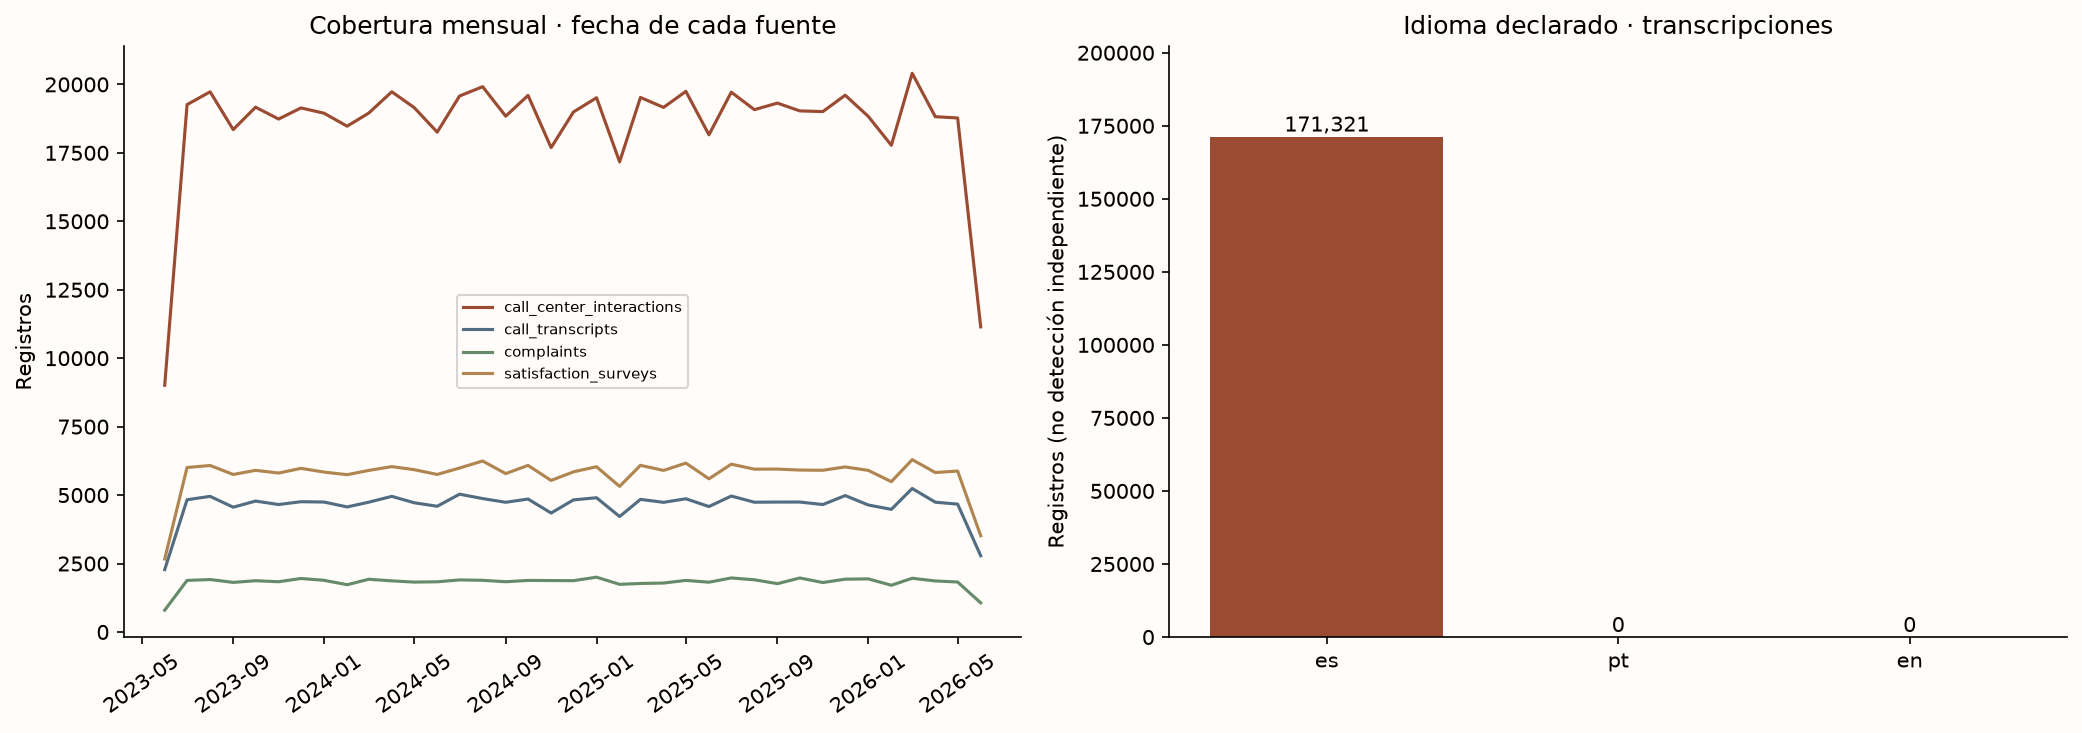

In [6]:
event_dates={'call_center_interactions':'interaction_date','call_transcripts':'process_date',
             'complaints':'creation_date','satisfaction_surveys':'survey_date'}
monthly_parts=[]; day_rows=[]
for t,c in event_dates.items():
    monthly_parts.append(con.execute(f'''SELECT {qs(t)} table_name,
        strftime(TRY_CAST({qi(c)} AS TIMESTAMP),'%Y-%m') AS month,count(*) AS "rows"
        FROM {qi(t)} WHERE TRY_CAST({qi(c)} AS TIMESTAMP) IS NOT NULL GROUP BY month''').df())
    days=con.execute(f'SELECT DISTINCT CAST(TRY_CAST({qi(c)} AS TIMESTAMP) AS DATE) d FROM {qi(t)} WHERE TRY_CAST({qi(c)} AS TIMESTAMP) IS NOT NULL ORDER BY d').df()['d']
    span=(days.max()-days.min()).days+1 if len(days) else 0
    mismatch=scalar(f'SELECT count(*) FROM {qi(t)} WHERE CAST(TRY_CAST({qi(c)} AS TIMESTAMP) AS DATE) <> TRY_CAST(process_date AS DATE)')
    day_rows.append({'table':t,'event_column':c,'observed_days':len(days),'calendar_span_days':span,
                     'missing_days_within_span':span-len(days),'event_vs_process_date_mismatch':mismatch})
monthly=save_df('monthly_activity',pd.concat(monthly_parts,ignore_index=True))
day_coverage=save_df('day_coverage',pd.DataFrame(day_rows))
declared=save_df('declared_languages',con.execute("SELECT coalesce(lower(detected_language),'no declarado') AS language_code,count(*) AS row_count FROM call_transcripts GROUP BY 1 ORDER BY 2 DESC").df().rename(columns={'language_code':'language','row_count':'rows'}))
markers={'es':{'quiero','quisiera','necesito','tengo','cuenta','gracias','hola','buenos','buenas','puede'},
         'pt':{'quero','gostaria','preciso','tenho','conta','obrigado','obrigada','olá','você','não'},
         'en':{'hello','please','thanks','account','want','need','my','the','balance'}}
def language_hint(s):
    words=set(re.findall(r'[^\W\d_]+',s.casefold(),flags=re.UNICODE))
    hits={lang:len(words & lexicon) for lang,lexicon in markers.items()}
    winner=max(hits,key=hits.get)
    return winner if hits[winner]>=2 and sum(v==hits[winner] for v in hits.values())==1 else 'indeterminado'
unique_texts=con.execute('SELECT source_table,clean_text,count(*) n FROM corpus GROUP BY 1,2').df()
unique_texts['language_hint']=unique_texts.clean_text.map(language_hint)
hints=save_df('language_hints',unique_texts.groupby(['source_table','language_hint'],as_index=False)['n'].sum())
display(temporal[temporal.table.isin(FOCUS)]); display(day_coverage); display(declared); display(hints)
fig,axes=plt.subplots(1,2,figsize=(14,5))
for i,t in enumerate(FOCUS):
    series=monthly[monthly.table_name==t].sort_values('month')
    axes[0].plot(pd.to_datetime(series.month),series.rows,label=t,color=COLORS[i])
axes[0].set_title('Cobertura mensual · fecha de cada fuente'); axes[0].set_ylabel('Registros'); axes[0].legend(fontsize=7)
axes[0].tick_params(axis='x',rotation=35)
plot_languages=declared.set_index('language')['rows'].reindex(list(dict.fromkeys(['es','pt','en']+declared.language.tolist())),fill_value=0).reset_index()
axes[1].bar(plot_languages.language,plot_languages.rows,color=COLORS[0]); axes[1].set_title('Idioma declarado · transcripciones')
axes[1].set_ylabel('Registros (no detección independiente)')
for i,r in plot_languages.iterrows(): axes[1].text(i,r.rows,f'{r.rows:,}',ha='center',va='bottom')
axes[1].margins(y=.18)
fig.tight_layout();show_fig(fig,'02_tiempo_idioma')

## 5. Texto, etiquetas y baseline de intención

Se ejecuta el clasificador local existente de Nexqori sobre textos únicos y se pondera por sus frecuencias. Son **sugerencias de reglas, no etiquetas correctas ni porcentajes calibrados**. No se utiliza el motivo histórico como entrada del clasificador. Se inspecciona la concentración del texto y se cruza con categorías registradas sólo después de comprobar vínculos de interacción y cliente.

No se muestran textos ni identificadores individuales en salidas del notebook. El corpus limpio está disponible exclusivamente en la carpeta privada para revisión local.

,recorded_label,row_count
0,consulta_general,162864
1,sin etiqueta,8457


,source_table,rows,unique_texts,top1_pct,top5_pct,mentions_saldo_rows,repeated_text_extra_rows
0,call_transcripts,171321,42,30.092633,67.609925,171321,171279
1,complaints,67095,5,20.239958,100.000000,0,67090
2,satisfaction_surveys,101196,13,13.459030,66.679513,0,101183


,source_table,baseline_intent,n
0,call_transcripts,balance,171321
1,complaints,movements,13580
2,complaints,services,13194
3,complaints,unknown,40321
4,satisfaction_surveys,human,16127
5,satisfaction_surveys,services,10370
6,satisfaction_surveys,unknown,74699


,total_transcripts,missing_interaction,customer_mismatch
0,171321,0,0


,declared_has_transcript,interactions,with_file
0,False,514975,0
1,True,171321,171321


,reason_category,transcripts,mentions_saldo,unique_customer_texts
0,Transaccional,59786,59786,42
1,Producto,37658,37658,42
2,Queja,29198,29198,42
3,Técnico,25691,25691,42
4,Comercial,13808,13808,42
5,Retención,5180,5180,42


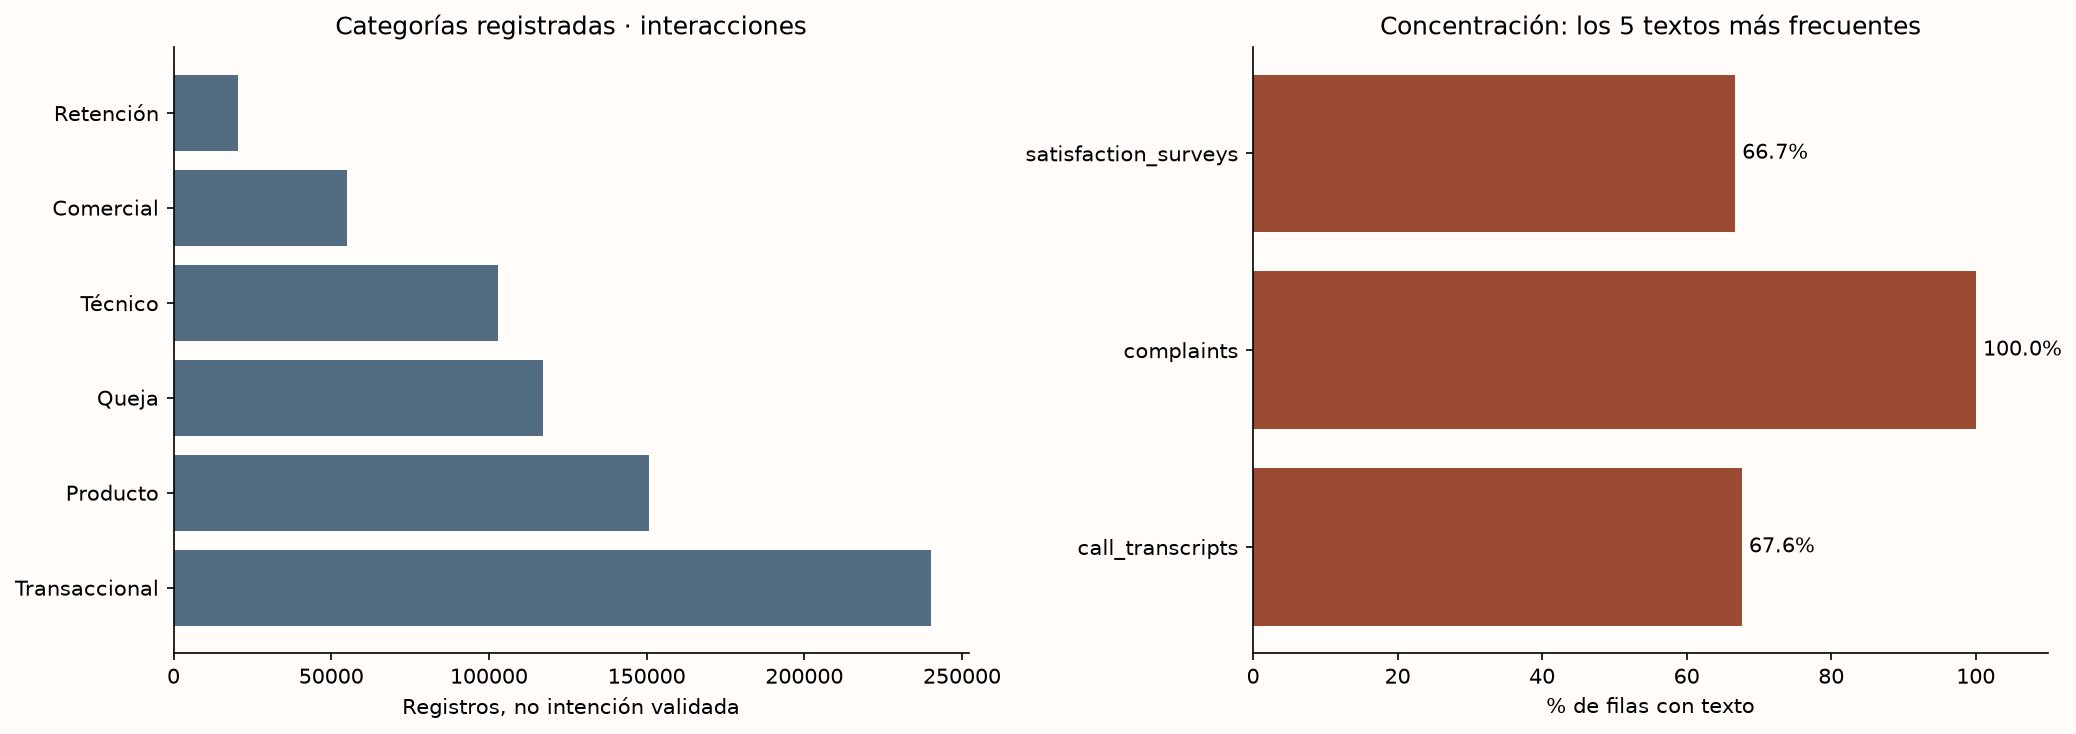

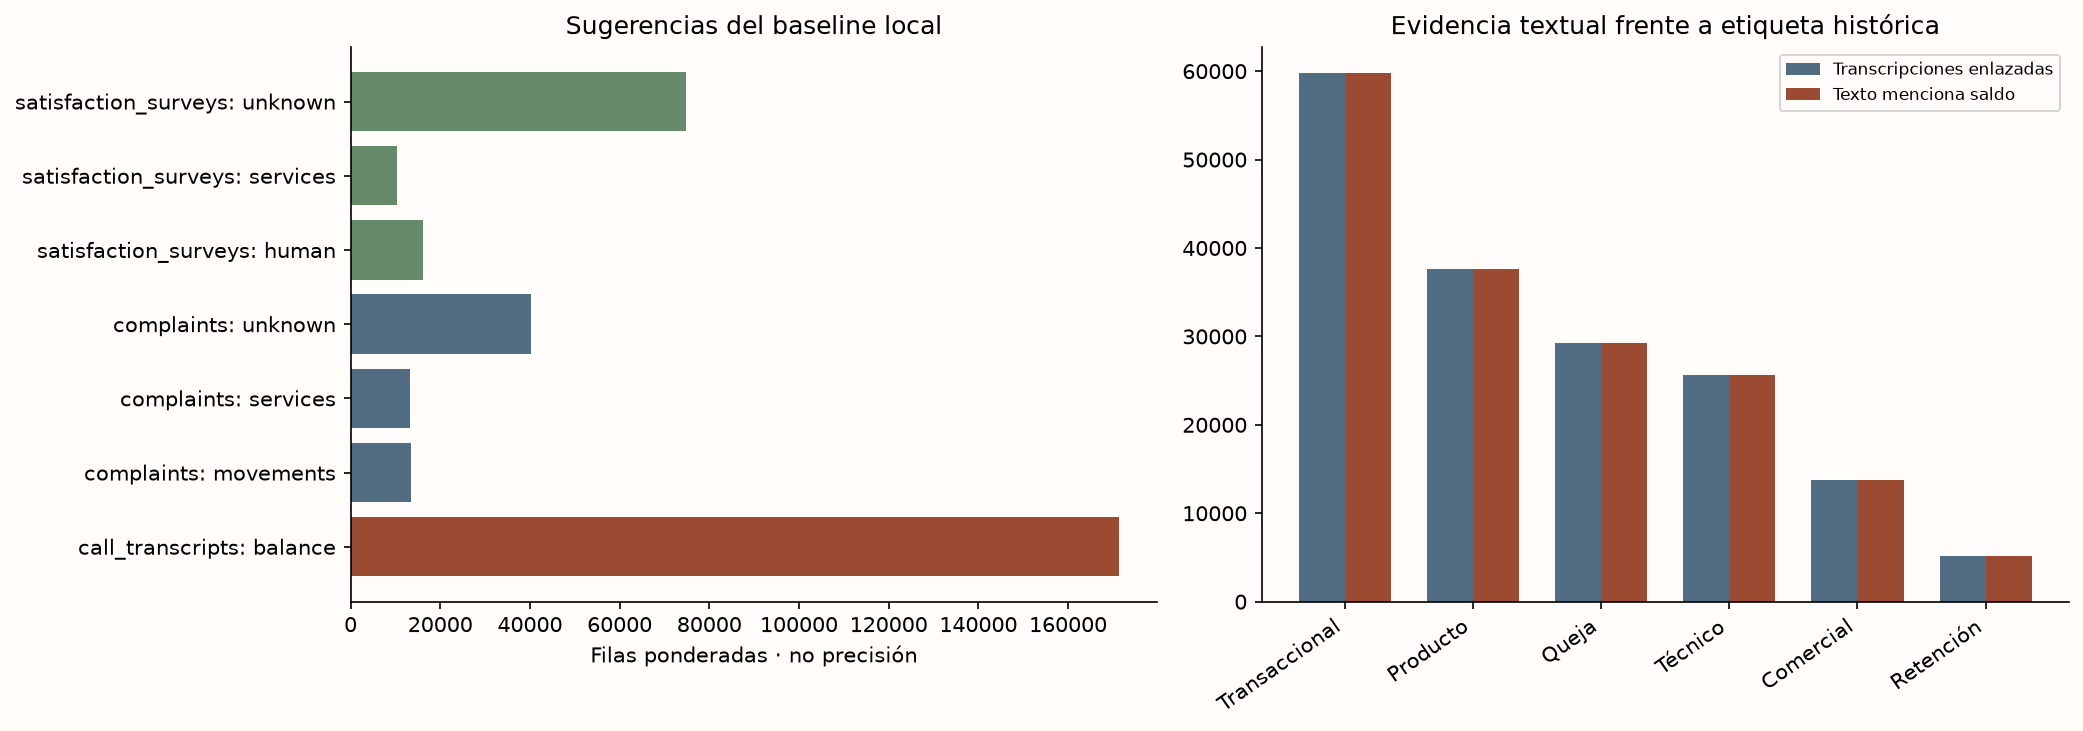

In [7]:
sys.path.insert(0,str(ROOT)) if str(ROOT) not in sys.path else None
from backend.assistant import classify
unique_texts['baseline_intent']=unique_texts.clean_text.map(classify)
unique_texts['mentions_saldo']=unique_texts.clean_text.str.contains(r'\bsaldo\b',case=False,regex=True)
baseline=save_df('baseline_intents',unique_texts.groupby(['source_table','baseline_intent'],as_index=False)['n'].sum())
concentration_rows=[]
for t,g in unique_texts.groupby('source_table'):
    n=int(g.n.sum()); counts=g.n.sort_values(ascending=False)
    concentration_rows.append({'source_table':t,'rows':n,'unique_texts':len(g),
        'top1_pct':100*int(counts.iloc[0])/n,'top5_pct':100*int(counts.head(5).sum())/n,
        'mentions_saldo_rows':int(g.loc[g.mentions_saldo,'n'].sum()),
        'repeated_text_extra_rows':n-len(g)})
concentration=save_df('text_concentration',pd.DataFrame(concentration_rows))
interaction_duplicate=int(summary.loc[summary.table=='call_center_interactions','duplicate_key_extra_rows'].iloc[0])
if interaction_duplicate: raise ValueError('IDs de interacción repetidos: revisar antes de unir textos y etiquetas.')
link=con.execute('''SELECT count(*) total_transcripts,
 count(*) FILTER (WHERE i.interaction_id IS NULL) missing_interaction,
 count(*) FILTER (WHERE i.interaction_id IS NOT NULL AND t.customer_id IS DISTINCT FROM i.customer_id) customer_mismatch
 FROM call_transcripts t LEFT JOIN call_center_interactions i USING(interaction_id)''').df()
save_df('transcript_links',link)
label_cross=save_df('text_vs_reason',con.execute('''SELECT coalesce(i.reason_category,'sin categoría') reason_category,
 count(*) transcripts,count(*) FILTER (WHERE regexp_matches(lower(t.customer_text),'(^|[^a-z])saldo([^a-z]|$)')) mentions_saldo,
 count(DISTINCT t.customer_text) unique_customer_texts
 FROM call_transcripts t JOIN call_center_interactions i ON t.interaction_id=i.interaction_id AND t.customer_id=i.customer_id
 GROUP BY 1 ORDER BY 2 DESC''').df())
availability=save_df('transcript_availability',con.execute('''SELECT i.has_transcript declared_has_transcript,
 count(*) interactions,count(*) FILTER (WHERE t.interaction_id IS NOT NULL) with_file
 FROM call_center_interactions i LEFT JOIN (SELECT DISTINCT interaction_id,customer_id FROM call_transcripts) t
 ON i.interaction_id=t.interaction_id AND i.customer_id=t.customer_id GROUP BY 1''').df())
reasons=save_df('contact_reasons',con.execute('SELECT reason_category,count(*) AS "rows" FROM call_center_interactions GROUP BY 1 ORDER BY 2 DESC').df())
recorded_labels=save_df('recorded_intent_labels',con.execute("SELECT coalesce(detected_intents,'sin etiqueta') AS recorded_label,count(*) AS row_count FROM call_transcripts GROUP BY 1 ORDER BY 2 DESC").df())
display(recorded_labels)
display(concentration);display(baseline);display(link);display(availability);display(label_cross)
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].barh(reasons.reason_category.fillna('sin dato'),reasons.rows,color=COLORS[1])
axes[0].set_title('Categorías registradas · interacciones');axes[0].set_xlabel('Registros, no intención validada')
axes[1].barh(concentration.source_table,concentration.top5_pct,color=COLORS[0])
axes[1].set_xlim(0,110);axes[1].set_title('Concentración: los 5 textos más frecuentes');axes[1].set_xlabel('% de filas con texto')
for i,r in concentration.iterrows(): axes[1].text(r.top5_pct+1,i,f'{r.top5_pct:.1f}%',va='center')
fig.tight_layout();show_fig(fig,'03_categorias_repeticion')
fig,axes=plt.subplots(1,2,figsize=(14,5))
for i,(t,g) in enumerate(baseline.groupby('source_table')):
    axes[0].barh([f'{t}: {s}' for s in g.baseline_intent],g.n,color=COLORS[i])
axes[0].set_title('Sugerencias del baseline local');axes[0].set_xlabel('Filas ponderadas · no precisión')
x=np.arange(len(label_cross));axes[1].bar(x-.18,label_cross.transcripts,width=.36,color=COLORS[1],label='Transcripciones enlazadas')
axes[1].bar(x+.18,label_cross.mentions_saldo,width=.36,color=COLORS[0],label='Texto menciona saldo')
axes[1].set_xticks(x,label_cross.reason_category,rotation=35,ha='right');axes[1].set_title('Evidencia textual frente a etiqueta histórica');axes[1].legend(fontsize=8)
fig.tight_layout();show_fig(fig,'04_intenciones_coherencia')

## 6. Validación, conclusiones y siguiente paso

Los controles siguientes validan cálculos y conservación de filas, no certifican la calidad del origen. No se asigna una intención verdadera a partir del nombre de una categoría. Se mantienen dominios separados: comentario posterior, descripción de reclamo y pedido del cliente no son intercambiables.

In [8]:
checks=[]
def check(name,ok): checks.append({'check':name,'passed':bool(ok)})
check('Tablas inventariadas y perfiladas coinciden',set(summary.table)==set(groups))
check('Todos los campos perfilados',len(profile)==int(summary['columns'].sum()))
check('Nulos y blancos no superan filas',bool((profile.missing_total<=profile.rows).all()))
check('Tipos inválidos no superan no vacíos',bool((profile.invalid_cast_nonmissing<=profile.rows-profile.missing_total).all()))
for t in FOCUS:
    n=int(summary.loc[summary.table==t,'rows'].iloc[0])
    check('Conservación filas '+t,scalar(f'SELECT count(*) FROM {qi(t)}')==n)
    check('Parquet legible '+t,scalar(f'SELECT count(*) FROM read_parquet({qs((OUT/"private"/(t+"_clean.parquet")).as_posix())})')==n)
for _,r in text_stats.iterrows():
    check('Baseline reconcilia '+r.source_table,int(baseline.loc[baseline.source_table==r.source_table,'n'].sum())==r.rows_with_text)
    check('Grupos de texto <= filas '+r.source_table,r.normalized_groups<=r.rows_with_text)
check('Idiomas declarados reconcilian',int(declared.rows.sum())==int(summary.loc[summary.table=='call_transcripts','rows'].iloc[0]))
check('Enlace no multiplica transcripciones',int(link.total_transcripts.iloc[0])==int(summary.loc[summary.table=='call_transcripts','rows'].iloc[0]))
# Comprueba que ningún archivo fuente cambió de tamaño/mtime durante el análisis.
check('Originales sin cambios observados',all((DATA/r['relative_path']).stat().st_size==r['bytes'] and (DATA/r['relative_path']).stat().st_mtime_ns==r['mtime_ns'] for r in inventory))
check_frame=save_df('validation',pd.DataFrame(checks));display(check_frame)
assert all(r['passed'] for r in checks),'Falló una comprobación: revisar results/validation.csv'

total=int(summary.rows.sum());trow=concentration[concentration.source_table=='call_transcripts'].iloc[0]
missing_pct=100*int(profile.missing_total.sum())/int((summary.rows*summary['columns']).sum())
lines=[
 '# Conclusiones del análisis inicial',
 f'- Fuente real: `{DATA}`. Censo de {len(inventory):,} CSV, {len(summary)} tablas, {total:,} filas y {len(profile)} columnas sumadas entre tablas.',
 f'- Calidad estructural: {int(summary.exact_duplicate_extra_rows.sum()):,} filas duplicadas exactas adicionales; {int(summary.duplicate_key_extra_rows.sum()):,} repeticiones adicionales de clave no nula; {missing_pct:.2f}% de celdas nulas/vacías. Un valor nulo no es automáticamente un error de negocio.',
 f'- Conversiones inválidas no vacías: {int(profile.invalid_cast_nonmissing.sum()):,}. Tipos esperados son reglas semánticas; los CSV se preservan como texto.',
 f'- Transcripciones: {int(trow.rows):,} textos de cliente disponibles; {int(trow.unique_texts):,} variantes limpias exactas; {int(trow.mentions_saldo_rows):,} mencionan saldo. La repetición limita la diversidad para evaluar nuevas intenciones.',
 '- Los meses inicial y final pueden ser parciales; no comparar sus conteos como meses completos. Cobertura temporal detallada en temporal_coverage.csv; process_date y fecha del evento no son equivalentes. No se conoce zona horaria ni disponibilidad histórica exacta de desenlaces.',
 '- Idioma declarado en transcripciones: '+', '.join(f'{r.language}: {int(r.rows):,}' for _,r in declared.iterrows())+'. Acento no acredita idioma; los indicios léxicos son exploratorios.',
 '- Comparar text_vs_reason.csv antes de usar etiquetas: mencionar saldo bajo otra categoría no prueba por sí solo cuál etiqueta sería correcta, pero exige revisión. No entrenar con reason_category o detected_intents sin validar.',
 '- Conservar grupos de textos y traducciones juntos al dividir desarrollo/validación/test; no dividir al azar las filas repetidas.',
 '- Crear un conjunto revisado ES/PT y regresión EN con ambiguas, negaciones, varias intenciones y derivación humana. Identificar ejemplos del equipo y del organizador por separado.',
 '- Las sugerencias del baseline no tienen probabilidad calibrada ni miden exactitud. No se llamó a Jev/LLM ni se entrenó un modelo.',
 f'- Validación: {len(checks)} controles satisfactorios. La app no fue modificada. Derivados individuales sólo en private/; no publicar ni enviar externamente.'
]
if not declared.language.str.lower().isin(['pt','pt-br','pt-pt','portuguese','português']).any():
    lines.insert(7,'- No se observó portugués declarado en las transcripciones; no afirmar cobertura PT a partir de este corpus.')
conclusions='\n\n'.join(lines)
(OUT/'results/CONCLUSIONES.md').write_text(conclusions+'\n',encoding='utf-8')
display(Markdown(conclusions))
save_json('run.json',{'finished_at_lima':datetime.now(ZoneInfo('America/Lima')).isoformat(),
    'dataset_root':str(DATA),'files':len(inventory),'tables':len(summary),'rows':total,
    'elapsed_seconds':round(time.perf_counter()-START,2),'python':platform.python_version(),
    'versions':{'duckdb':duckdb.__version__,'pandas':pd.__version__,'numpy':np.__version__,'matplotlib':matplotlib.__version__},
    'baseline_sha256':hashlib.sha256((ROOT/'backend/assistant.py').read_bytes()).hexdigest(),
    'source_manifest_sha256':hashlib.sha256((OUT/'private/input_manifest.json').read_bytes()).hexdigest(),
    'checks_passed':len(checks),'scope':'all discovered known CSV tables, no sampling',
    'cleaned_tables':FOCUS,'external_requests':0,'gpu_used':False})
con.close()
print('Notebook ejecutado. Resultados en',OUT)

,check,passed
0,Tablas inventariadas y perfiladas coinciden,True
1,Todos los campos perfilados,True
2,Nulos y blancos no superan filas,True
3,Tipos inválidos no superan no vacíos,True
4,Conservación filas call_center_interactions,True
5,Parquet legible call_center_interactions,True
6,Conservación filas call_transcripts,True
7,Parquet legible call_transcripts,True
8,Conservación filas complaints,True
9,Parquet legible complaints,True


# Conclusiones del análisis inicial

- Fuente real: `C:\Users\santi\Documents\Projects\nexqori-dataset`. Censo de 7,671 CSV, 13 tablas, 23,495,188 filas y 260 columnas sumadas entre tablas.

- Calidad estructural: 0 filas duplicadas exactas adicionales; 0 repeticiones adicionales de clave no nula; 29.82% de celdas nulas/vacías. Un valor nulo no es automáticamente un error de negocio.

- Conversiones inválidas no vacías: 0. Tipos esperados son reglas semánticas; los CSV se preservan como texto.

- Transcripciones: 171,321 textos de cliente disponibles; 42 variantes limpias exactas; 171,321 mencionan saldo. La repetición limita la diversidad para evaluar nuevas intenciones.

- Los meses inicial y final pueden ser parciales; no comparar sus conteos como meses completos. Cobertura temporal detallada en temporal_coverage.csv; process_date y fecha del evento no son equivalentes. No se conoce zona horaria ni disponibilidad histórica exacta de desenlaces.

- Idioma declarado en transcripciones: es: 171,321. Acento no acredita idioma; los indicios léxicos son exploratorios.

- No se observó portugués declarado en las transcripciones; no afirmar cobertura PT a partir de este corpus.

- Comparar text_vs_reason.csv antes de usar etiquetas: mencionar saldo bajo otra categoría no prueba por sí solo cuál etiqueta sería correcta, pero exige revisión. No entrenar con reason_category o detected_intents sin validar.

- Conservar grupos de textos y traducciones juntos al dividir desarrollo/validación/test; no dividir al azar las filas repetidas.

- Crear un conjunto revisado ES/PT y regresión EN con ambiguas, negaciones, varias intenciones y derivación humana. Identificar ejemplos del equipo y del organizador por separado.

- Las sugerencias del baseline no tienen probabilidad calibrada ni miden exactitud. No se llamó a Jev/LLM ni se entrenó un modelo.

- Validación: 21 controles satisfactorios. La app no fue modificada. Derivados individuales sólo en private/; no publicar ni enviar externamente.

Notebook ejecutado. Resultados en C:\Users\santi\Documents\Projects\nexqori\notebooks\intentions
